## Chapter 4. Path tracing: Homework
### Initialize

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import drjit as dr
import mitsuba as mi

from util import imshow_compare, imshow_compare_many

mi.set_variant('cuda_ad_rgb', 'llvm_ad_rgb')
print(f"{mi.variant() = }\n")

cbox_scene = mi.load_dict(mi.cornell_box())
vmis_scene = mi.load_file("./scene/veach-mis/scene.xml")
vmis_delta_scene = mi.load_file("./scene/veach-mis/scene_delta.xml")

scene_dict = {'Cornell box': cbox_scene, 'Veach MIS': vmis_scene, 'Veach MIS w/ Dirac Delta': vmis_delta_scene}

# -------------------- Assertions --------------------
assert isinstance(cbox_scene, mi.Scene)
assert isinstance(vmis_scene, mi.Scene)
assert isinstance(vmis_delta_scene, mi.Scene)

jitc_llvm_init(): LLVM API initialization failed ..


mi.variant() = 'cuda_ad_rgb'



### See GT

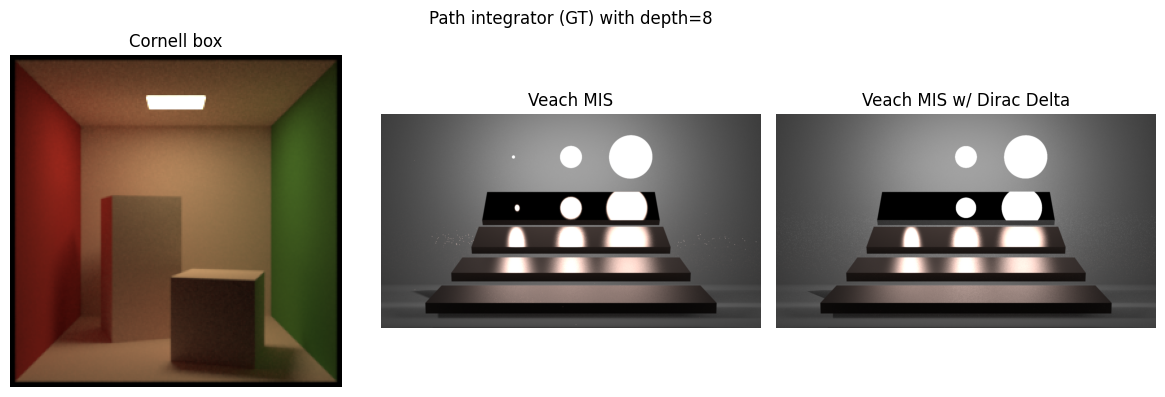

In [2]:
# -------------------- Parameters --------------------
figsize = (12, 4)
spp = 256
depth = 8

# -------------------- Visualize --------------------
integrator = mi.load_dict({'type': 'path', 'max_depth': depth, 'rr_depth': depth})
img_gt_dict = dict()

fig, axes = plt.subplots(1, len(scene_dict), figsize=figsize)
for ax, (label, scene) in zip(axes, scene_dict.items()):
    img = mi.render(scene, integrator=integrator, spp=spp)
    img_gt_dict[label] = img

    ax.imshow(mi.Bitmap(dr.clip(img, 0, 1)**(1/2.2)))
    ax.set_title(label)
    ax.set_axis_off()
fig.suptitle(f"Path integrator (GT) with {depth=}")
fig.tight_layout()

-----
## Ver. 0.7 Path Integrator with a fixed detph

In [ ]:
class PathIntegrator(mi.ad.integrators.common.ADIntegrator):
    def __init__(self, props = mi.Properties()):
        super().__init__(props)
        self.max_depth = int(props.get('max_depth', 8))
    
    def sample(self,
               mode: dr.ADMode, # NOT USED NOW (differentiable rendering)
               scene: mi.Scene,
               sampler: mi.Sampler,
               ray: mi.Ray3f,
               active: mi.Bool,
               **kwargs # Absorbs unused arguments
               ):
        #################### TODO start ####################
        bsdf_ctx = mi.BSDFContext()
        L = mi.Spectrum(0.0)
        β = mi.Spectrum(1)


        prev_si = dr.zeros(mi.SurfaceInteraction3f)
        prev_bsdf_pdf = mi.Float(1.0) 
        prev_bsdf_delta = mi.Bool(True)

        for i in range(self.max_depth):
            # ---------- Direct emission ----------
            si = scene.ray_intersect(ray) # $p_{i+1}$
            
            bsdf = si.bsdf(ray)

            ds = mi.DirectionSample3f(scene,si,prev_si) # W_{i,i+1}

            mis = self.mis_weight(prev_bsdf_pdf,scene.pdf_emitter_direction(prev_si,ds,~prev_bsdf_delta)) # w_B(W_{i,i+1,B})

            L += β * mis * ds.emitter.eval(si) # \beta_i w_B(W_{i,i+1,B}) L_{e,i+1,i}

            if i == self.max_depth-1:
                break
            #bsdf = si.bsdf()
            # ---------- Emitter sampling ----------
            ds, em_weight = scene.sample_emitter_direction(si, sampler.next_2d()) # W_{i+1, i+2, E}, \frac{L_{e,i+2,i+1}}{p_E(W_{i+1,i+2,E})}

            wo = si.to_local(ds.d)
            bsdf_value_em, bsdf_pdf_em = bsdf.eval_pdf(bsdf_ctx,si,wo) # f_{s,i+2,i+1,i}^\bot, p_B(W_{i+1,i+2,E})
            mis_em = dr.select(ds.delta,1,self.mis_weight(ds.pdf,bsdf_pdf_em)) # w_E(W_{i+1,i+2,E})

            L += β * mis_em * bsdf_value_em * em_weight # beta_i w_E(W_{i+1,i+2,E})\frac{f_{s,i+2,i+1,i}^{\bot}L_{e,i+2,i+1}}{p_E(W_{i+1,i+2,E})}

            # ---------- BSDF sampling ----------
            bsdf_sample, bsdf_weight = bsdf.sample(bsdf_ctx, # $\omega_{i+1,i+2}$
                                                   si,
                                                   sampler.next_1d(),
                                                   sampler.next_2d()
                                                  )
            ray = si.spawn_ray(si.to_world(bsdf_sample.wo))

            β *= bsdf_weight # \beta_i+1
            prev_si = si
            prev_bsdf_pdf = bsdf_sample.pdf 
            prev_bsdf_delta = mi.has_flag(bsdf_sample.sampled_type, mi.BSDFFlags.Delta)

        #################### TODO end ####################
        return L, active, [], None
    
    def mis_weight(self, pdf_a, pdf_b):
        # w = 0
        # w = pdf_a / (pdf_a + pdf_b)
        a2 = dr.sqr(pdf_a)
        b2 = dr.sqr(pdf_b)
        w = a2**2 / (a2**2 + b2**2)
        return dr.select(dr.isfinite(w), w, 0)

mi.register_integrator("mypath", lambda props: PathIntegrator(props))

Render the result

In [9]:
spp = 2048
mypath = mi.load_dict({'type': "mypath", 'max_depth': 8})
img_ours_dict = {}
for label, scene in scene_dict.items():
    img = mi.render(scene, integrator=mypath, spp=spp)
    img_ours_dict[label] = img

C:\Users\nyhvi\AppData\Local\Temp\ipykernel_35716\1788304850.py:67: DeprecationWarning: sqr() is deprecated, please use square(arg)
  a2 = dr.sqr(pdf_a)
C:\Users\nyhvi\AppData\Local\Temp\ipykernel_35716\1788304850.py:68: DeprecationWarning: sqr() is deprecated, please use square(arg)
  b2 = dr.sqr(pdf_b)


Visualize

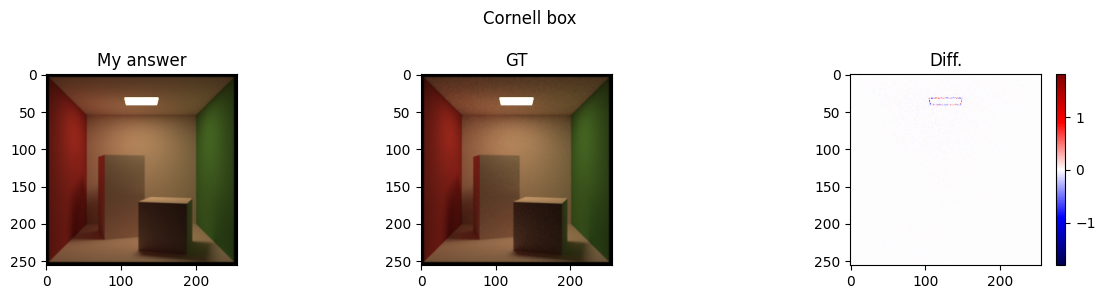

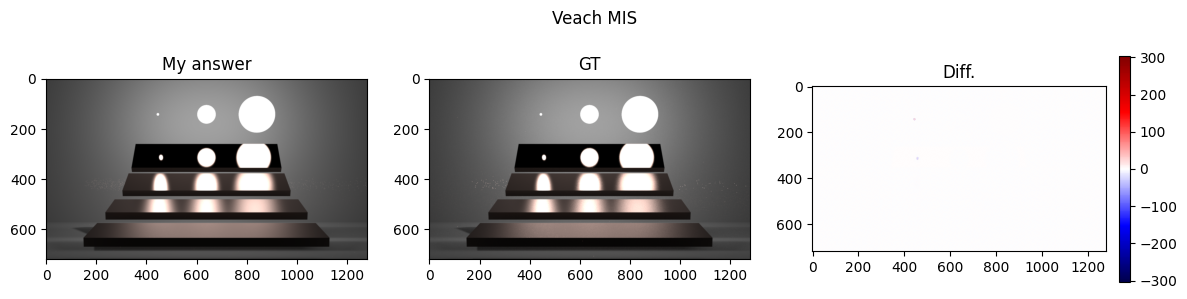

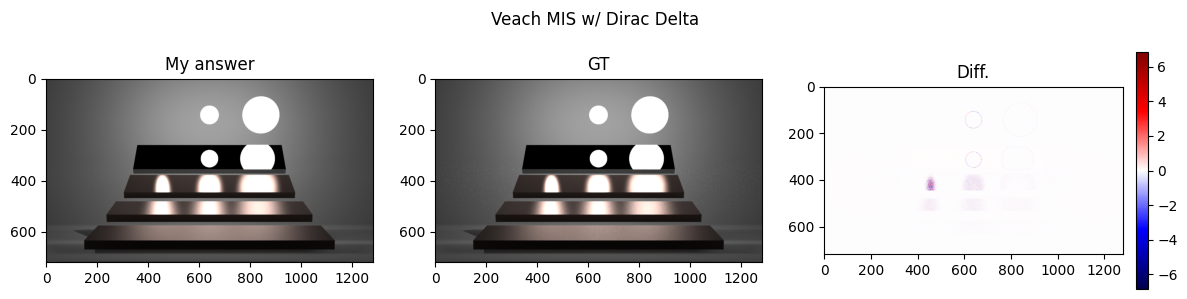

In [7]:
for label in scene_dict:
    imshow_compare(img_ours_dict[label].numpy(), img_gt_dict[label].numpy(),
                   figsize=(12, 3), suptitle=label)